<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and attractors
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
centers = [np.pi/6, np.pi/3, np.pi, 5*np.pi/3, 11*np.pi/6]  # 5-node ring
theta = np.pi / 3

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

nodes = [gaussian(c, sigma, A) * np.cos(theta) for c in centers]
phi = sum(nodes)
history = [phi.copy()]


In [2]:
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)
    if t == 150:
        phi -= nodes[2]  # collapse central node
    if t % 50 == 0:
        history.append(phi.copy())


In [3]:
def correlation(a, b):
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    return (np.dot(a, b) / (na * nb)) if (na > 0 and nb > 0) else 0.0

def collapse_index(phi, eps=1e-3):
    return np.mean(np.abs(phi) < eps)

corrs = [[correlation(h, n) for n in nodes] for h in history]
collapses = [collapse_index(h) for h in history]


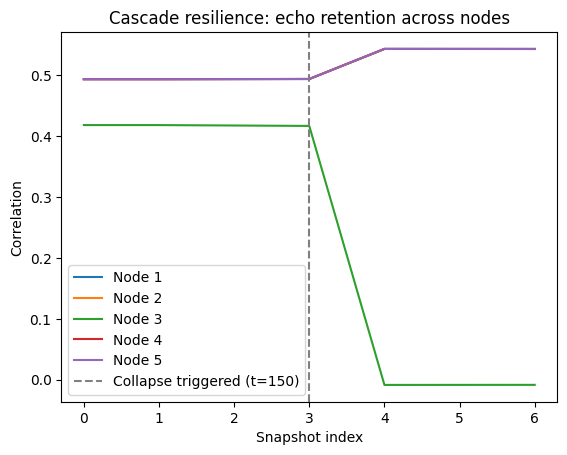

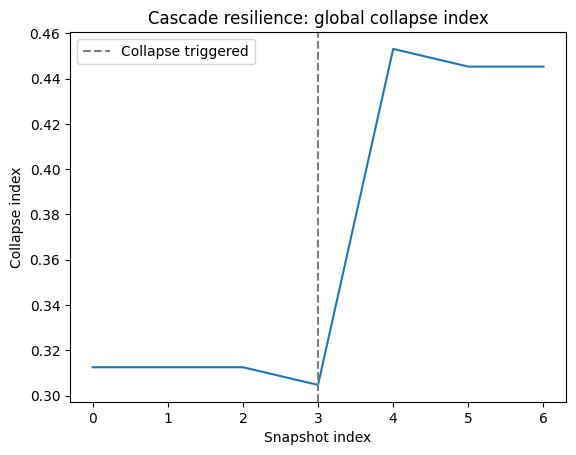

In [4]:
# Correlation plot
for i in range(5):
    plt.plot([c[i] for c in corrs], label=f"Node {i+1}")
plt.axvline(x=3, color='gray', linestyle='--', label="Collapse triggered (t=150)")
plt.xlabel("Snapshot index")
plt.ylabel("Correlation")
plt.title("Cascade resilience: echo retention across nodes")
plt.legend()
plt.show()

# Collapse index
plt.plot(collapses)
plt.axvline(x=3, color='gray', linestyle='--', label="Collapse triggered")
plt.xlabel("Snapshot index")
plt.ylabel("Collapse index")
plt.title("Cascade resilience: global collapse index")
plt.legend()
plt.show()
